In [7]:
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams['font.family'] = 'Malgun Gothic'
mpl.rcParams['axes.unicode_minus'] = False

In [2]:
import os
import pandas as pd

# 경로 설정
folder_path = r"C:\Users\USER\Desktop\data\cleaned"

# 지원되는 파일 확장자
supported_ext = ['.csv', '.xlsx', '.parquet']

# 파일 목록 가져오기 (csv, xlsx, parquet)
file_list = [f for f in os.listdir(folder_path) if os.path.splitext(f)[1] in supported_ext]

# 파일별 컬럼 확인
for file_name in file_list:
    file_path = os.path.join(folder_path, file_name)
    ext = os.path.splitext(file_name)[1]

    try:
        if ext == '.csv':
            df = pd.read_csv(file_path, nrows=5)
        elif ext == '.xlsx':
            df = pd.read_excel(file_path, nrows=5)
        elif ext == '.parquet':
            df = pd.read_parquet(file_path)
        else:
            print(f"❌ 지원하지 않는 형식: {file_name}")
            continue

        print(f"✅ {file_name} - 컬럼 목록:")
        print(df.columns.tolist())
        print('-' * 60)

    except Exception as e:
        print(f"❗️{file_name} 읽기 오류: {e}")

✅ distribution_centers_EDA.csv - 컬럼 목록:
['id', 'name', 'latitude', 'longitude']
------------------------------------------------------------
✅ events_EDA.csv - 컬럼 목록:
['id', 'user_id', 'sequence_number', 'session_id', 'created_at', 'ip_address', 'city', 'state', 'postal_code', 'browser', 'traffic_source', 'uri', 'event_type']
------------------------------------------------------------
✅ inventory_items_EDA.csv - 컬럼 목록:
['id', 'product_id', 'created_at', 'sold_at', 'cost', 'product_category', 'product_name', 'product_brand', 'product_retail_price', 'product_department', 'product_sku', 'product_distribution_center_id', 'created_year', 'created_month', 'created_day', 'created_weekday']
------------------------------------------------------------
✅ orders_EDA.csv - 컬럼 목록:
['order_id', 'user_id', 'status', 'gender', 'created_at', 'returned_at', 'shipped_at', 'delivered_at', 'num_of_item', 'is_returned', 'shipping_days', 'lead_time']
---------------------------------------------------------

### H16	장바구니 전략보다는 단품 특화 마케팅이 더 효과적일 수 있다

- 한 번에 여러 상품을 사는 고객보다, 단일 상품을 구매하는 고객의 반응률 및 전환률이 더 높을 수 있다.

In [17]:
# 데이터 불러오기
import pandas as pd
orders = pd.read_csv("C:/Users/USER/Desktop/data/cleaned/orders_EDA.csv")
order_items = pd.read_csv("C:/Users/USER/Desktop/data/cleaned/order_items_EDA.csv")

In [9]:
# 주문당 상품 수 계산
order_item_count = order_items.groupby('order_id').size().reset_index(name='item_count')

In [13]:
# 주문을 단품 / 다품목으로 나누기
order_item_count['order_type'] = order_item_count['item_count'].apply(lambda x: '단품' if x == 1 else '다품목')

In [19]:
# 위 분류를 통해 재구매율, 반품률 등 비교하기
orders = orders.merge(order_item_count[['order_id', 'order_type']], on='order_id', how='left')

In [23]:
# 단품 / 다품목 별로 비교 지표 계산
# 예: 반품률
return_rate = orders.groupby('order_type')['is_returned'].mean()

# 예: 평균 리드타임
lead_time_avg = orders.groupby('order_type')['lead_time'].mean()

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_18352\48050539.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=return_rate, x='order_type', y='is_returned', palette='Set2')


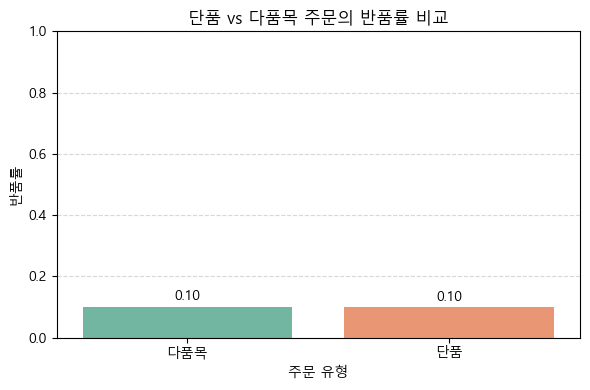

In [33]:
# 반품률 시각화
import matplotlib.pyplot as plt
import seaborn as sns

# 반품률 계산
return_rate = orders.groupby('order_type')['is_returned'].mean().reset_index()

plt.figure(figsize=(6, 4))
sns.barplot(data=return_rate, x='order_type', y='is_returned', palette='Set2')
plt.title("단품 vs 다품목 주문의 반품률 비교")
plt.ylabel("반품률")
plt.xlabel("주문 유형")
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# 수치 표시
for index, row in return_rate.iterrows():
    plt.text(x=index, y=row['is_returned'] + 0.02, s=f"{row['is_returned']:.2f}", ha='center')

plt.tight_layout()
plt.show()

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_18352\439461372.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=lead_time_avg, x='order_type', y='lead_time', palette='Set1')


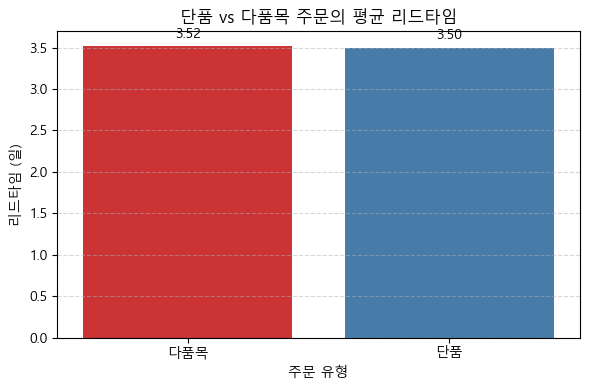

In [35]:
# 리드타임 시각화

# 평균 리드타임 계산
lead_time_avg = orders.groupby('order_type')['lead_time'].mean().reset_index()

# 시각화
plt.figure(figsize=(6, 4))
sns.barplot(data=lead_time_avg, x='order_type', y='lead_time', palette='Set1')
plt.title("단품 vs 다품목 주문의 평균 리드타임")
plt.ylabel("리드타임 (일)")
plt.xlabel("주문 유형")
plt.grid(axis='y', linestyle='--', alpha=0.5)

# 수치 표시
for index, row in lead_time_avg.iterrows():
    plt.text(x=index, y=row['lead_time'] + 0.1, s=f"{row['lead_time']:.2f}", ha='center')

plt.tight_layout()
plt.show()

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_18352\2539119257.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=sale_price_avg, x='order_type', y='sale_price', palette='coolwarm')


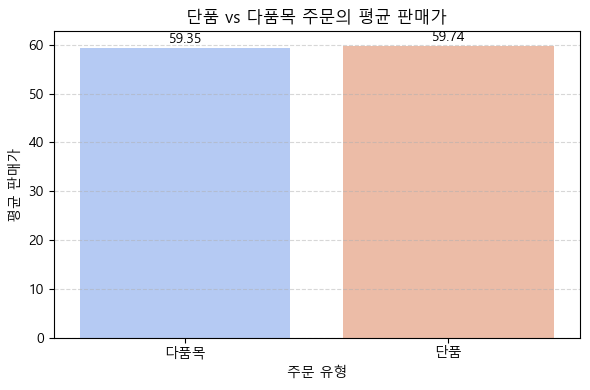

In [37]:
# 평균 구매 금액 시각화

# order_items와 order_type을 합쳐야 함
order_items = order_items.merge(order_item_count[['order_id', 'order_type']], on='order_id', how='left')

# 평균 판매가 계산
sale_price_avg = order_items.groupby('order_type')['sale_price'].mean().reset_index()

# 시각화
plt.figure(figsize=(6, 4))
sns.barplot(data=sale_price_avg, x='order_type', y='sale_price', palette='coolwarm')
plt.title("단품 vs 다품목 주문의 평균 판매가")
plt.ylabel("평균 판매가")
plt.xlabel("주문 유형")
plt.grid(axis='y', linestyle='--', alpha=0.5)

# 수치 표시
for index, row in sale_price_avg.iterrows():
    plt.text(x=index, y=row['sale_price'] + 1, s=f"{row['sale_price']:.2f}", ha='center')

plt.tight_layout()
plt.show()

- 반품률은 둘 다 0.1로 동일해 인사이트를 찾기 어려움

- 단품 주문의 평균 리드타임이 0.02일 빠름.
- 차이는 미미하지만, 단품 주문이 약간 더 빠르게 배송되는 경향이 있음을 볼 수 있음.
- 다품목의 경우 복잡한 포장, 품절 리스크 등 처리 지연 가능성이 단품에 비해 높다고 봄
- 배송 속도 측면에서 단품 특화 전략이 소폭 우위를 보일 수 있음.

- 단품 주문의 경우 평균 판매가가 다품목 주문보다 약 0.66% 높은 것을 확인할 수 있음.
- 이는 단품 마케딩 시 단가가 더 높은 제품군에 집중했을 가능성도 있음
- 고객이 단품으로 주문하는 경우, 할인 유인 없이도 고가 제품에 반응할 수도 있을거라고 생각함.
- 단품 특화 마케딩은 단가가 높은 프리미엄 제품에 유리할 수 있음.

#### 최종 결론
- 반품률은 유효한 비교 불가, 그러나 리드타임과 평균 판매가 측면에서 단품 주문이 다품목보다 소폭 우위를 보이는 것을 확인할 수 있었음. 특히 판매가에서 단품이 더 높게 나타나, 단품 중심의 고단가 마케팅 전략이 수익성 향상에 기여할 수 있는 여지를 보여줌

### H17	구매 이력이 없는 유저는 관심 제품/탐색 활동도 적었을 것이다

In [42]:
# 사용자 그룹 나누기
orders = pd.read_csv("C:/Users/USER/Desktop/data/cleaned/orders_EDA.csv")
events = pd.read_csv("C:/Users/USER/Desktop/data/cleaned/events_EDA.csv")

# 구매 이용자 set
buyers = set(orders['user_id'].unique())

# events에 구매 여부 추가
events['is_buyer'] = events['user_id'].apply(lambda x: '구매 유저' if x in buyers else '미구매 유저')

In [44]:
# 유저별 이벤트 수
event_counts = events.groupby(['user_id', 'is_buyer']).size().reset_index(name='event_count')

In [46]:
# 구매 여부별 평균 탐색 활동량 비교
event_stats = event_counts.groupby('is_buyer')['event_count'].agg(['mean', 'median', 'count']).reset_index()
print(event_stats)

  is_buyer       mean  median  count
0    구매 유저  16.314819    10.0  78137
1   미구매 유저  16.518616    10.0   1907


C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_18352\3986503067.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=event_counts, x='is_buyer', y='event_count', palette='Set3')


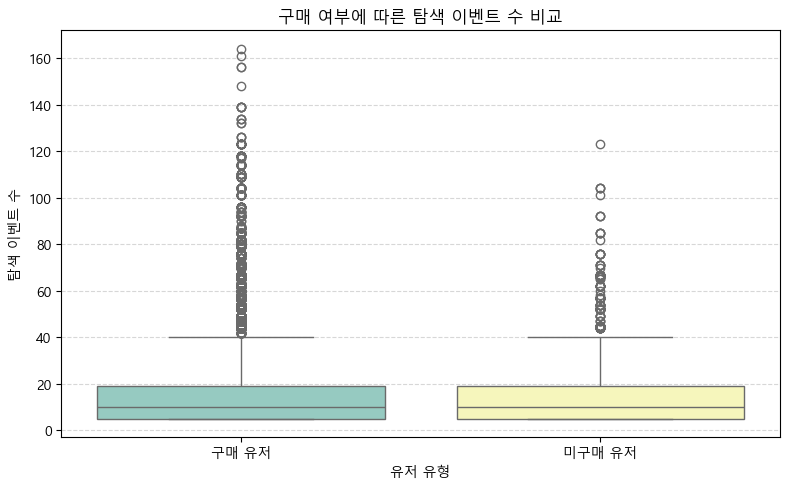

In [50]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rc('font', family='Malgun Gothic')
mpl.rcParams['axes.unicode_minus'] = False

plt.figure(figsize=(8, 5))
sns.boxplot(data=event_counts, x='is_buyer', y='event_count', palette='Set3')
plt.title("구매 여부에 따른 탐색 이벤트 수 비교")
plt.xlabel("유저 유형")
plt.ylabel("탐색 이벤트 수")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

#### 탐색 이벤트 수 평균 비교
- 미구매 유저가 오히려 탐색 이벤트 수 평균이 조금 더 높음 (16.52 > 16.31)
- 중앙값은 10으로 차이 없음

#### 탐색 이벤트 수 분포 유사
- 이벤트 수의 중간값이 같고 평균도 거의 비슷해서 구매 여부와 탐색량 간에 명확한 차이는 없음

#### 결론
- 단순 탐색량만으로 구매 유무 구분 어려움
- 즉, 구매 이력이 없는 유저도 탐색 활동은 구매 유저와 거의 비슷하거나 오히려 많음
- 단순히 '탐색 활동이 적어서 구매가 안 일어난다'라는 가설은 틀렸다고 볼 수 있음.

### H18	가입 후 14일 이내 구매를 유도하는 전략이 부족했을 것이다

In [56]:
import pandas as pd
from datetime import datetime

# 데이터 불러오기
users = pd.read_csv("C:/Users/USER/Desktop/data/cleaned/users_EDA.csv", parse_dates=['created_at'])
orders = pd.read_csv("C:/Users/USER/Desktop/data/cleaned/orders_EDA.csv", parse_dates=['created_at'])

# 유저별 첫 구매일
first_orders = orders.groupby('user_id')['created_at'].min().reset_index()
first_orders.columns = ['user_id', 'first_order_date']

# 유저 가입일과 첫 구매일 조인
user_purchase = pd.merge(users[['id', 'created_at']], first_orders, left_on='id', right_on='user_id', how='inner')
user_purchase.rename(columns={'created_at': 'signup_date'}, inplace=True)

# signup_date를 datetime으로 변환 
user_purchase['signup_date'] = pd.to_datetime(user_purchase['signup_date'])

# 가입 후 첫 구매까지 걸린 일수 계산
user_purchase['days_to_purchase'] = (user_purchase['first_order_date'] - user_purchase['signup_date']).dt.days

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_18352\2372098920.py:5: DtypeWarning: Columns (8) have mixed types. Specify dtype option on import or set low_memory=False.
  users = pd.read_csv("C:/Users/USER/Desktop/data/cleaned/users_EDA.csv", parse_dates=['created_at'])


In [60]:
# 14일 이내 구매 여부 파생 변수 만들기
user_purchase['within_14_days'] = user_purchase['days_to_purchase'] <= 14

In [62]:
#비율 계산 및 시각화
purchase_window_stats = user_purchase['within_14_days'].value_counts(normalize=True).reset_index()
purchase_window_stats.columns = ['within_14_days', 'ratio']
print(purchase_window_stats)

   within_14_days     ratio
0           False  0.938109
1            True  0.061891


C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_18352\3102362627.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=purchase_window_stats, x='within_14_days', y='ratio', palette='pastel')


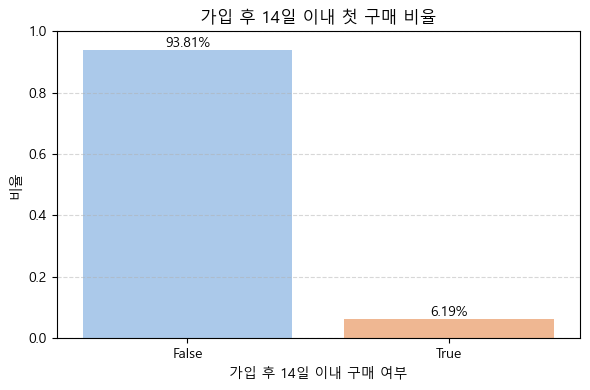

In [64]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl
mpl.rc('font', family='Malgun Gothic')
mpl.rcParams['axes.unicode_minus'] = False

plt.figure(figsize=(6, 4))
sns.barplot(data=purchase_window_stats, x='within_14_days', y='ratio', palette='pastel')

# 수치 표시
for index, row in purchase_window_stats.iterrows():
    plt.text(x=index, y=row['ratio'] + 0.01, s=f"{row['ratio']*100:.2f}%", ha='center')

plt.title("가입 후 14일 이내 첫 구매 비율")
plt.xlabel("가입 후 14일 이내 구매 여부")
plt.ylabel("비율")
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

#### 초기 구매 유도 전략 부족
- 전체 유저 중 단 6.2% 정도의 유저만이 가입 후 14일 이내 첫 구매
- 이는 가입 직후의 구매 전환 전략이 거의 작동하지 않았음을 강하게 보여줌.

#### 전환 시점이 과도하게 늦음
- 대부분의 유저는 구매를 2주이상 지연하거나 가입 후 이탈했을 가능성도 높음.

### H19	장바구니에 담기만 하고 구매하지 않은 제품은 고가일 가능성이 높다 (보류)

In [69]:
# 데이터 불러오기
events = pd.read_csv("C:/Users/USER/Desktop/data/cleaned/events_EDA.csv")
order_items = pd.read_csv("C:/Users/USER/Desktop/data/cleaned/order_items_EDA.csv")
products = pd.read_csv("C:/Users/USER/Desktop/data/cleaned/products_EDA.csv")

# 1. 장바구니에 담긴 이벤트 필터링
cart_events = events[events['event_type'] == 'product_added'].copy()

# 이벤트에서 product_id 파싱 (uri 컬럼에서 추출해야 할 수도 있음)
# 예: '/products/1382' 같은 형식이면 숫자만 추출
cart_events['product_id'] = cart_events['uri'].str.extract(r'/products/(\d+)').astype('float')

# 2. 유저+제품 조합 중 실제 구매 여부 확인
order_products = order_items[['user_id', 'product_id']].drop_duplicates()
order_products['purchased'] = True

# 3. 장바구니 이벤트와 결합해 구매 여부 표시
cart_with_purchase = pd.merge(
    cart_events[['user_id', 'product_id']],
    order_products,
    on=['user_id', 'product_id'],
    how='left'
)

cart_with_purchase['purchased'] = cart_with_purchase['purchased'].fillna(False)

# 4. 제품 가격 붙이기
cart_with_purchase = pd.merge(
    cart_with_purchase,
    products[['id', 'retail_price']],
    left_on='product_id',
    right_on='id',
    how='left'
)

# 5. 그룹별 평균 가격 비교
price_comparison = cart_with_purchase.groupby('purchased')['retail_price'].agg(['mean', 'median', 'count']).reset_index()
price_comparison['purchased'] = price_comparison['purchased'].map({True: '구매함', False: '구매 안 함'})
print(price_comparison)

Empty DataFrame
Columns: [purchased, mean, median, count]
Index: []


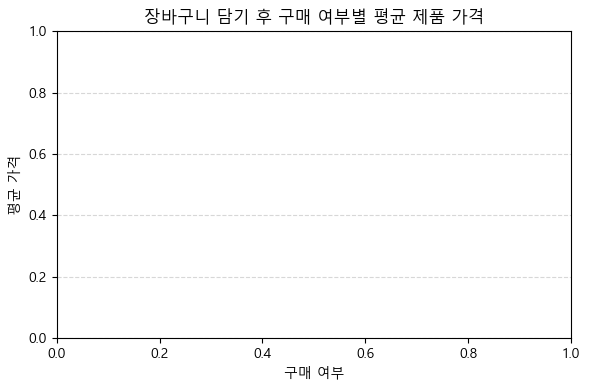

In [71]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl
mpl.rc('font', family='Malgun Gothic')
mpl.rcParams['axes.unicode_minus'] = False

plt.figure(figsize=(6, 4))
sns.barplot(data=price_comparison, x='purchased', y='mean', palette='Set2')

# 수치 라벨 추가
for i, row in price_comparison.iterrows():
    plt.text(i, row['mean'] + 1, f"{row['mean']:.2f}", ha='center')

plt.title("장바구니 담기 후 구매 여부별 평균 제품 가격")
plt.xlabel("구매 여부")
plt.ylabel("평균 가격")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### H20	장바구니 제품군은 카테고리 유사도가 높을 것이다

In [12]:
import pandas as pd

# 데이터 불러오기
order_items = pd.read_csv('C:/Users/USER/Desktop/data/cleaned/order_items_EDA.csv')
products = pd.read_csv('C:/Users/USER/Desktop/data/cleaned/products_EDA.csv')

# order_id별로 주문된 product_id 모으기
order_products = order_items.groupby('order_id')['product_id'].apply(list).reset_index()

# 2개 이상 상품이 포함된 주문만 필터링
multi_item_orders = order_products[order_products['product_id'].apply(len) > 1]

# 상품 정보와 조인하기 위해 explode
multi_item_orders_exploded = multi_item_orders.explode('product_id')
multi_item_orders_exploded = multi_item_orders_exploded.merge(products[['id', 'category']], left_on='product_id', right_on='id', how='left')

# 주문별 카테고리 수 계산 (다양성)
category_stats = multi_item_orders_exploded.groupby('order_id')['category'].nunique().reset_index(name='unique_categories')
category_stats['item_count'] = multi_item_orders_exploded.groupby('order_id')['category'].count().values
category_stats['all_same_category'] = category_stats['unique_categories'] == 1

# 요약 결과
result = category_stats['all_same_category'].value_counts(normalize=True).reset_index()
result.columns = ['all_same_category', 'ratio']
print(result)

   all_same_category     ratio
0              False  0.952692
1               True  0.047308


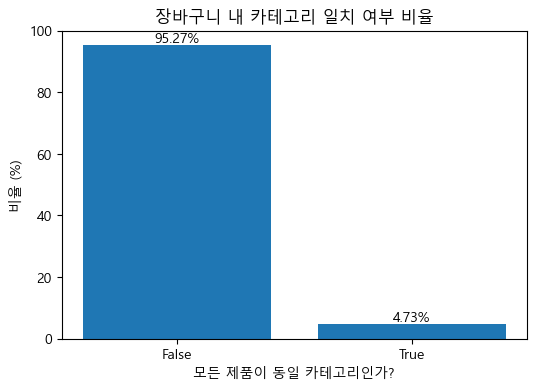

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.bar(result['all_same_category'].astype(str), result['ratio'] * 100)
plt.ylabel('비율 (%)')
plt.xlabel('모든 제품이 동일 카테고리인가?')
plt.title('장바구니 내 카테고리 일치 여부 비율')
plt.ylim(0, 100)
for i, v in enumerate(result['ratio'] * 100):
    plt.text(i, v + 1, f'{v:.2f}%', ha='center')
plt.show()

### 결론
- 장바구니에 담긴 제품들의 카테고리가 모두 동일한 경우는 드물다는 것을 보여줌(4.7%)
- 대부분의 장바구니는 다양한 카테고리의 제품들로 구성되어 있음을 확인

### H21	판매율이 낮은 상품은 입고 전략 재검토가 필요하다

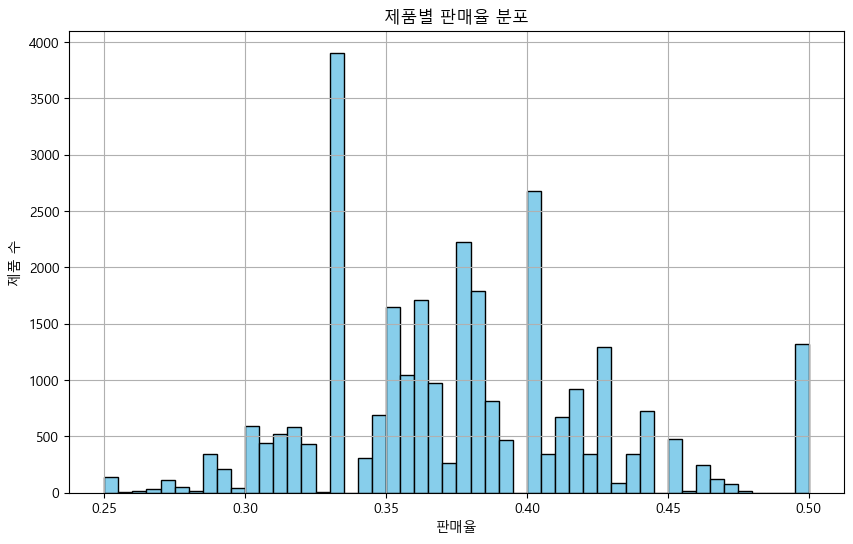

,name,category,stock_count,sold_count,sell_through_rate
4373,Not Your Daughter's Jeans Women's Boot Cut Jean,Jeans,4,1,0.25
10737,Hanes Womens Comfortsoft Waisband Boy Briefs,Intimates,8,2,0.25
2759,Fleece Pant Set - Misses' Sizes,Active,8,2,0.25
15331,Ray-Ban RB 3466 Sunglasses,Plus,12,3,0.25
12589,Nipple Concealers Petal Tops,Intimates,8,2,0.25
10764,Fruit Of The Loom Womens 6 Pack Low Rise Brief,Intimates,8,2,0.25
15165,A Pea in the Pod: Maternity Tank With Shelf Bra,Maternity,4,1,0.25
2911,August Silk Women's Flat Knit Turtleneck,Active,8,2,0.25
2941,Royal Robbins Women's Urban Pea Coat,Active,8,2,0.25
2980,Hot Chillys Women's MTF 4000 Solid Tight,Active,4,1,0.25


In [26]:
# CSV 불러오기 
inventory_items = pd.read_csv('C:/Users/USER/Desktop/data/cleaned/inventory_items_EDA.csv')
order_items = pd.read_csv('C:/Users/USER/Desktop/data/cleaned/order_items_EDA.csv')
products = pd.read_csv('C:/Users/USER/Desktop/data/cleaned/products_EDA.csv')

# 제품별 입고 수량
stock_count = inventory_items.groupby('product_id').size().reset_index(name='stock_count')

# 실제 판매된 재고 (sold_at이 null이 아닌 경우)
sold_items = inventory_items[inventory_items['sold_at'].notna()]
sold_count = sold_items.groupby('product_id').size().reset_index(name='sold_count')

# 병합
product_sales = pd.merge(stock_count, sold_count, on='product_id', how='left')
product_sales['sold_count'] = product_sales['sold_count'].fillna(0)

# 판매율 계산
product_sales['sell_through_rate'] = product_sales['sold_count'] / product_sales['stock_count']

# 제품 정보 붙이기
product_sales = pd.merge(product_sales, products[['id', 'name', 'category']], left_on='product_id', right_on='id', how='left')

# 판매율 분포 시각화
plt.figure(figsize=(10, 6))
plt.hist(product_sales['sell_through_rate'], bins=50, color='skyblue', edgecolor='black')
plt.title('제품별 판매율 분포')
plt.xlabel('판매율')
plt.ylabel('제품 수')
plt.grid(True)
plt.show()

# 판매율 낮은 TOP 제품 (판매율 10% 이하)
low_performers = product_sales[product_sales['sell_through_rate'] <= 0.3].sort_values(by='sell_through_rate')
low_performers_top10 = low_performers[['name', 'category', 'stock_count', 'sold_count', 'sell_through_rate']].head(10)

low_performers_top10

#### 이렇게 보기엔 약간 애매한 감이 있어서 재고 수 및 판매율을 각각 점수로 환산, 낮은거 부터 출력

In [42]:
from sklearn.preprocessing import MinMaxScaler

df = product_sales.copy()

# 결측치 제거
df = df.dropna(subset=['stock_count', 'sell_through_rate'])

# 점수 스케일링
scaler = MinMaxScaler()

# 판매율 낮을수록 점수 높음 (1 - normalized)
df['sell_score'] = 1 - scaler.fit_transform(df[['sell_through_rate']])

# 재고 많을수록 점수 높음
df['stock_score'] = scaler.fit_transform(df[['stock_count']])

# 총 점수 계산
df['total_risk_score'] = df['sell_score'] + df['stock_score']

# 낮은 판매율 & 높은 재고 기준으로 정렬
sorted_df = df.sort_values(by='total_risk_score', ascending=False)

# 하위 10개 제품 출력
print(
    sorted_df[['product_id', 'name', 'stock_count', 'sell_through_rate',
               'sell_score', 'stock_score', 'total_risk_score']].head(10)
)

       product_id                                               name  \
14808       14868  PAIGE Women's Maternity Union Skyline Straight...   
21016       21086               Kenneth Cole Men's Straight Leg Jean   
23400       23471            Volcom Frayer Jean Cutoff Short - Men's   
14996       15056  Motherhood Maternity: Plus Size 3 Pack Materni...   
17579       17641  American Apparel Polka Dot Flex Fleece Zip Hoodie   
27551       27625  Mens Print Hot Body Boxer Swimsuit Gary Majdel...   
18731       18795  Life is Good Men's King Of The Grill Short Sle...   
19956       20025  Calvin Klein Mens 2 Button Gray Tan Slim Fit W...   
14239       14299                     Military Wool Jeep Cap - Olive   
27938       28012  Free Country Men's Island Palm Plaid Free C Bo...   

       stock_count  sell_through_rate  sell_score  stock_score  \
14808           49           0.306122    0.775510     0.839286   
21016           52           0.326923    0.692308     0.892857   
23400    

### 결론
- 재고가 많고 판매율이 낮은 상품들에 대해서는 입고 전략의 재검토가 필요해보인다.

### H22	제품 회전율이 높은 경우에는 시즌성 요인이 크다

In [13]:
# 제품별 총 판매량 기준으로 회전율 높은 제품 추출
top_products = product_sales.sort_values(by='total_sales', ascending=False).head(10)

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_7720\727165816.py:5: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  monthly_sales['year_month'] = monthly_sales['sold_at'].dt.to_period('M')
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_7720\727165816.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  monthly_sales['year_month'] = monthly_sales['sold_at'].dt.to_period('M')


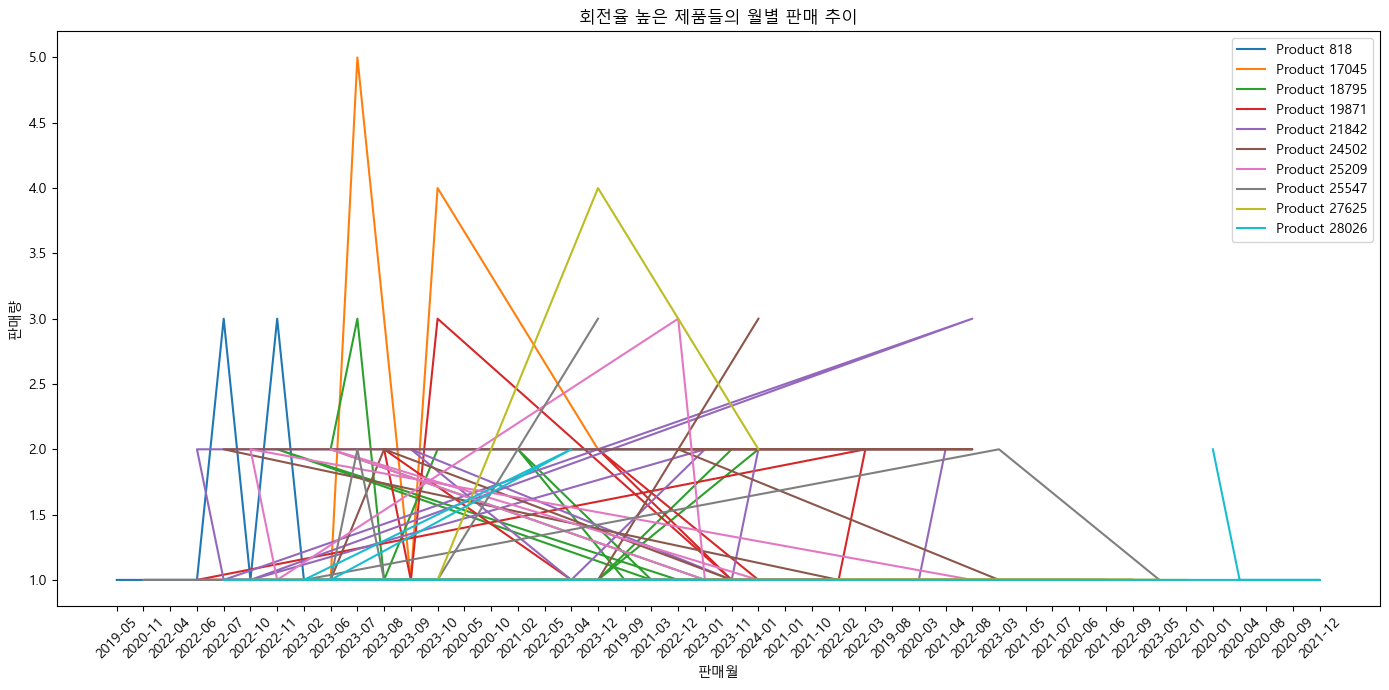

In [15]:
import matplotlib.pyplot as plt

# 월별 + 제품별 판매량 집계
monthly_sales = inventory[inventory['product_id'].isin(top_products['product_id'])]
monthly_sales['year_month'] = monthly_sales['sold_at'].dt.to_period('M')
grouped = monthly_sales.groupby(['product_id', 'year_month']).size().reset_index(name='sales')

# 시각화
plt.figure(figsize=(14, 7))
for product_id in grouped['product_id'].unique():
    data = grouped[grouped['product_id'] == product_id]
    plt.plot(data['year_month'].astype(str), data['sales'], label=f'Product {product_id}')

plt.title('회전율 높은 제품들의 월별 판매 추이')
plt.xlabel('판매월')
plt.ylabel('판매량')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

- 회전률이 높은 10개의 제품의 ID를 가져와본 결과 월별 판매 추이가 고르지 못한 것을 알 수 있음.
- 이는 매달 고루 팔린다는 것이 아니라 특정 달에만 유독 잘 팔린다는 것을 시사함.
- 그렇기에 제품 회전율이 높은 경우에는 시즌성 요인이 크다고 볼 수 있음.